In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
from importlib import reload
import functions_kde_js
import clustering_functions
reload(functions_kde_js)
reload(clustering_functions)
from seed_fix import set_seeds

from functions_kde_js import (compute_joint_kdes, compute_js_divergence, categorize_count, cluster_similarity_analysis,
                              compute_js_divergence_mD, create_months,
                              read_scale_monthly_kde_mD, read_scale_monthly_kde, create_joint_similarity_matrix, find_mlcv_bandwidth, run_md_sensitivity_analysis, run_cluster_threshold_sensitivity, fit_cluster_kdes_with_mlcv_bandwidth)
from my_imports import pd, np, plt, sns, StandardScaler
from clustering_functions import load_scale_filter_data, clustering_process
set_seeds()

In [ ]:
results = run_md_sensitivity_analysis(
    global_start_date="01-2023",
    global_end_date="01-2025",
    plot=True
)

In [17]:
global_start_date = "01-2023"
global_end_date = "01-2025"
months = create_months(global_start_date, global_end_date)
cluster_objects_pool = {}
monthly_kde = {}
monthly_kde_mD = {}
cluster_kdes = {}
reference_clusters = {}
ref_month = global_start_date
ref_n_clusters = 0
metric = "silhouette"
js_lim_month = 0.18
js_lim_cluster = 0.18
stream_order = []
kmeans_objects_dict = {}
similarity_matrix = []
import copy
from my_imports import StandardScaler
scaler = StandardScaler()
x_train = load_scale_filter_data(start_m=months[0], end_m=months[1])
band_width, _, _ = find_mlcv_bandwidth(x_train)
_ = scaler.fit(x_train)
js_per_feature_mat = []
js_mat_time_order = []
js_md_per_month = {}
all_monthly_kde = {}
all_clusters_kde = {}
for idx in range(len(months)-1):
    print("current_month_pair", months[idx], months[idx+1])
    current_month_pair = (months[idx], months[idx+1])
    current_month = current_month_pair[0]
    # if statement for first month only
    if current_month == global_start_date:
        print("analyzing first month in the data.")
        x_train, monthly_kde[current_month] = read_scale_monthly_kde(scaler,current_month_pair[0],current_month_pair[1], band_width)
        _, monthly_kde_mD[current_month] = read_scale_monthly_kde_mD(scaler,current_month_pair[0],current_month_pair[1], band_width)
        all_monthly_kde[current_month] = monthly_kde[current_month].copy()
        # instantiate the class object for the class
        x_train, km_labels, kmeans= clustering_process(x_train, scaler, current_month, metric)
        h_cluster = fit_cluster_kdes_with_mlcv_bandwidth(x_train=x_train,km_labels=km_labels)
        # create a kde for each cluster
        cluster_kdes[current_month] = compute_joint_kdes(x_train, bandwidth=h_cluster, labels=km_labels)
        cluster_kdes[global_start_date] = {f"{global_start_date}_{str(k)}": v for k, v in cluster_kdes[global_start_date].items()}
        stream_order.append(global_start_date)
        kmeans_objects_dict[global_start_date] = kmeans
        cluster_objects_pool.update({key: value[0] for key, value in  cluster_kdes[current_month].items()})
        ref_month = current_month
        all_clusters_kde.update({key: value[0] for key, value in  cluster_kdes[current_month].items()})
    else:
        x_train, monthly_kde[current_month] = read_scale_monthly_kde(scaler,current_month_pair[0],current_month_pair[1], band_width)
        _, monthly_kde_mD[current_month] = read_scale_monthly_kde_mD(scaler,current_month_pair[0],current_month_pair[1], band_width)
        js_md_per_month[current_month] = compute_js_divergence_mD(monthly_kde_mD[current_month], monthly_kde_mD[ref_month], 1000)
        all_monthly_kde[current_month] = monthly_kde[current_month].copy()
        # not only ref month but every month before
        js_dict = {}
        js_list = []

        for i in range(x_train.shape[1]):
            js = compute_js_divergence(monthly_kde[current_month][i], monthly_kde[ref_month][i], 1000)
            js_list.append(np.round(js, 5))
        js_dict[ref_month] = js_list
        if js_md_per_month[current_month] < js_lim_month:
            print(f"All values are less than {js_lim_month}")
            monthly_kde.pop(current_month, None)
            monthly_kde_mD.pop(current_month, None)
            cluster_kdes[current_month] = copy.deepcopy(cluster_kdes[ref_month])
            x_train, cluster_kdes = categorize_count(x_train, kmeans_objects_dict, cluster_kdes, ref_month, current_month, scaler)
            monthly_kde.pop(current_month, None)
            stream_order.append(ref_month)
            js_per_feature_mat.append(js_dict[ref_month])
            js_mat_time_order.append(current_month)
            continue
        else:
            js_per_feature_mat.append(js_dict[ref_month])
            js_mat_time_order.append(current_month)

        candidates_md = {}
        state = False
        for item in monthly_kde_mD:
            # pass the current month
            js_list_md = []
            if (item == current_month) or (item == ref_month):
                continue
            js = compute_js_divergence_mD(monthly_kde_mD[current_month], monthly_kde_mD[item], 1000)
            js_list_md.append(js)
            if js < js_lim_month:
                candidates_md[item]=js
                state = True


        if candidates_md:
            the_best_candidate = min(candidates_md, key=candidates_md.get)
            monthly_kde_mD.pop(current_month, None)
            cluster_kdes[current_month] = copy.deepcopy(cluster_kdes[the_best_candidate])
            ref_month = the_best_candidate
            x_train, cluster_kdes = categorize_count(x_train, kmeans_objects_dict, cluster_kdes, ref_month, current_month, scaler)
            monthly_kde.pop(current_month, None)
            state = True
            stream_order.append(ref_month)
            print("The most similar data batch is chosen to be", the_best_candidate)


        if not state:
            print(f"At least one value is {js_lim_month} or greater.")
            x_train, km_labels, kmeans= clustering_process(x_train, scaler, current_month, metric)
            cluster_kdes[current_month] = compute_joint_kdes(x_train, bandwidth=h_cluster, labels=km_labels)
            cluster_kdes[current_month] = {f"{current_month}_{str(k)}": v for k, v in cluster_kdes[current_month].items()}
            all_clusters_kde.update({key: value[0] for key, value in  cluster_kdes[current_month].items()})
            ref_month = current_month
            kmeans_objects_dict[current_month] = kmeans
            stream_order.append(current_month)
            kde_sim_dict = {key: value[0] for key, value in cluster_kdes[current_month].items()}
            kde_sim_dict = copy.deepcopy(kde_sim_dict)
            similarity_matrix = create_joint_similarity_matrix(cluster_objects_pool, kde_sim_dict, 1000)
            cluster_objects_pool, cluster_kdes = cluster_similarity_analysis(similarity_matrix, cluster_objects_pool, cluster_kdes, js_lim_cluster, current_month)

current_month_pair 01-2023 02-2023
analyzing first month in the data.
6, Number of Optimal Clusters for Month 01-2023


In [ ]:
results = run_cluster_threshold_sensitivity(
    all_clusters_kde=all_clusters_kde,
    plot=True
)

In [12]:
import plot_function_results
reload(plot_function_results)
from plot_function_results import drift_plot_v2, styled_step_plot_with_dots

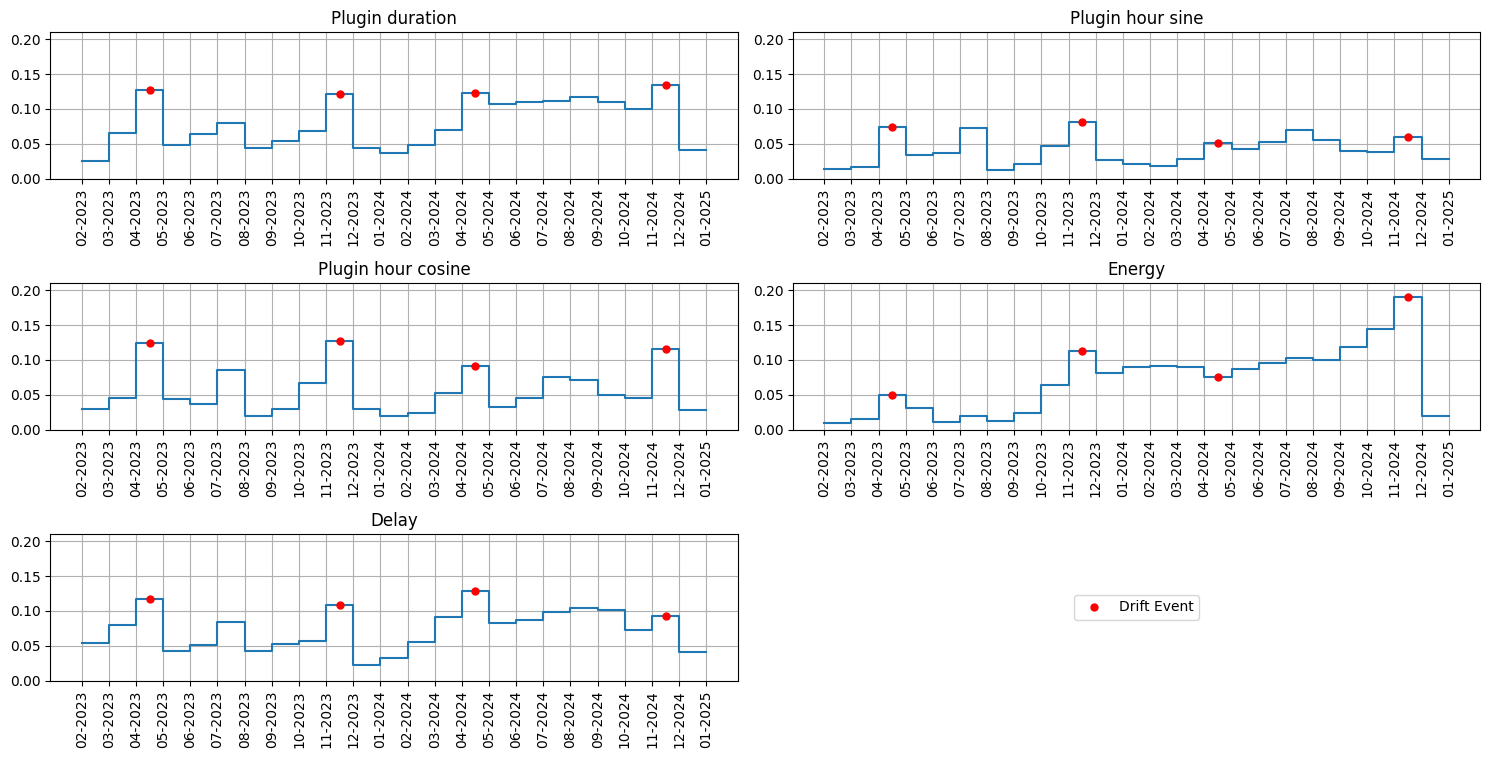

In [9]:
drift_plot_v2(js_per_feature_mat, js_mat_time_order, global_end_date,[2,9,14, 21])

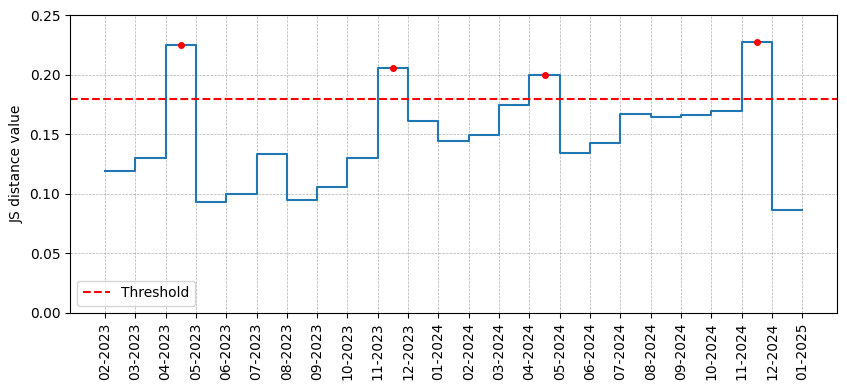

In [13]:
styled_step_plot_with_dots(js_md_per_month)

In [ ]:
results = run_cluster_threshold_sensitivity(
    all_clusters_kde=all_clusters_kde,
    plot=True
)